### Step 5：消融实验

消融1：固定轨迹和扰动，仅改变 LQR 的 $R$ 权重，比较收敛速度与控制量幅值。

In [19]:
# 配置环境
import numpy as np
import matplotlib.pyplot as plt
from pydrake.all import (
    AddMultibodyPlantSceneGraph,
    DirectCollocation,
    DiagramBuilder,
    FiniteHorizonLinearQuadraticRegulatorOptions,
    LogVectorOutput,
    MakeFiniteHorizonLinearQuadraticRegulator,
    MultibodyPlant,
    Parser,
    PiecewisePolynomial,
    Simulator,
    SnoptSolver,
    Solve,
    )
from underactuated import ConfigureParser

def settling_time(signal, ts, tol=0.05):
    target = 0.0
    within = np.where(np.abs(signal - target) < tol)[0]
    if len(within) == 0:
        return np.nan
    return ts[within[0]]

def solve_cartpole_dircol(
    num_time_samples=21,
    dt_min=0.05,
    dt_max=0.2,
    u_weight=1.0,
    time_weight=1.0,
    x_limit=None,
    u_limit=None,
    ):
    plant = MultibodyPlant(time_step=0.0)
    parser = Parser(plant)
    ConfigureParser(parser)
    parser.AddModelsFromUrl("package://underactuated/models/cartpole.urdf")
    plant.Finalize()
    context = plant.CreateDefaultContext()

    dircol = DirectCollocation(
        plant,
        context,
        num_time_samples=num_time_samples,
        minimum_time_step=dt_min,
        maximum_time_step=dt_max,
        input_port_index=plant.get_actuation_input_port().get_index(),
    )
    prog = dircol.prog()

    x0 = np.array([0.0, 0.0, 0.0, 0.0])
    xf = np.array([0.0, np.pi, 0.0, 0.0])
    prog.AddBoundingBoxConstraint(x0, x0, dircol.initial_state())
    prog.AddBoundingBoxConstraint(xf, xf, dircol.final_state())

    if x_limit is not None:
        for i in range(num_time_samples):
            prog.AddBoundingBoxConstraint(-x_limit, x_limit, dircol.state(i)[0])
    if u_limit is not None:
        for i in range(num_time_samples):
            prog.AddBoundingBoxConstraint(-u_limit, u_limit, dircol.input(i)[0])

    u = dircol.input()
    dircol.AddRunningCost(u_weight * u[0] ** 2)
    dircol.AddFinalCost(time_weight * dircol.time())

    state_guess = PiecewisePolynomial.FirstOrderHold(
        [0.0, 1.0], np.vstack((x0, xf)).T
    )
    input_guess = PiecewisePolynomial.FirstOrderHold(
        [0.0, 1.0], np.zeros((1, 2))
    )
    dircol.SetInitialTrajectory(input_guess, state_guess)

    solver = SnoptSolver()
    if solver.available():
        result = solver.Solve(prog)
    else:
        result = Solve(prog)

    if not result.is_success():
        print(" 求解失败：请调整约束或离散参数")
        return None, None

    xtraj = dircol.ReconstructStateTrajectory(result)
    utraj = dircol.ReconstructInputTrajectory(result)
    return xtraj, utraj

def solve_constrained_trajectory(scale=0.7):
    xtraj0, utraj0 = solve_cartpole_dircol()
    if xtraj0 is None:
        return None, None

    ts0 = np.linspace(xtraj0.start_time(), xtraj0.end_time(), 201)
    x_samples0 = xtraj0.vector_values(ts0)
    u_samples0 = utraj0.vector_values(ts0)
    x_max = float(np.max(np.abs(x_samples0[0, :])))
    u_max = float(np.max(np.abs(u_samples0[0, :])))
    L = scale * x_max
    u_limit = scale * u_max
    print(f"无约束极值: |x|max={x_max:.3f}, |u|max={u_max:.3f}")
    print(f"设置约束: |x|<=L={L:.3f}, |u|<=u_max={u_limit:.3f}")

    xtraj, utraj = solve_cartpole_dircol(x_limit=L, u_limit=u_limit)
    return xtraj, utraj

def simulate_tvlqr_with_R(xtraj, utraj, R_scale=1.0, x0_perturb=None):
    options = FiniteHorizonLinearQuadraticRegulatorOptions()
    options.x0 = xtraj
    options.u0 = utraj
    Q = np.diag([10.0, 50.0, 1.0, 5.0])
    R = np.array([[1.0 * R_scale]])
    options.Qf = Q

    builder = DiagramBuilder()
    plant, _ = AddMultibodyPlantSceneGraph(builder, time_step=0.0)
    parser = Parser(plant)
    ConfigureParser(parser)
    parser.AddModelsFromUrl("package://underactuated/models/cartpole.urdf")
    plant.Finalize()
    context = plant.CreateDefaultContext()
    options.input_port_index = plant.get_actuation_input_port().get_index()

    regulator = builder.AddSystem(
        MakeFiniteHorizonLinearQuadraticRegulator(
            plant,
            context,
            t0=utraj.start_time(),
            tf=utraj.end_time(),
            Q=Q,
            R=R,
            options=options,
        )
    )
    builder.Connect(regulator.get_output_port(0), plant.get_actuation_input_port())
    builder.Connect(plant.get_state_output_port(), regulator.get_input_port(0))

    state_logger = LogVectorOutput(plant.get_state_output_port(), builder)
    input_logger = LogVectorOutput(regulator.get_output_port(0), builder)

    diagram = builder.Build()
    simulator = Simulator(diagram)
    sim_context = simulator.get_mutable_context()
    plant_context = plant.GetMyMutableContextFromRoot(sim_context)

    x0 = np.ravel(xtraj.value(utraj.start_time()))
    if x0_perturb is not None:
        x0 = x0 + np.ravel(x0_perturb)
    plant.SetPositionsAndVelocities(plant_context, x0)

    simulator.AdvanceTo(utraj.end_time())
    state_log = state_logger.FindLog(sim_context)
    input_log = input_logger.FindLog(sim_context)
    return state_log, input_log

运行消融：对比不同 $R$ 权重下的跟踪效果与控制幅值。

我们手动调节R矩阵的权重

无约束极值: |x|max=1.114, |u|max=108.492
设置约束: |x|<=L=0.780, |u|<=u_max=75.944


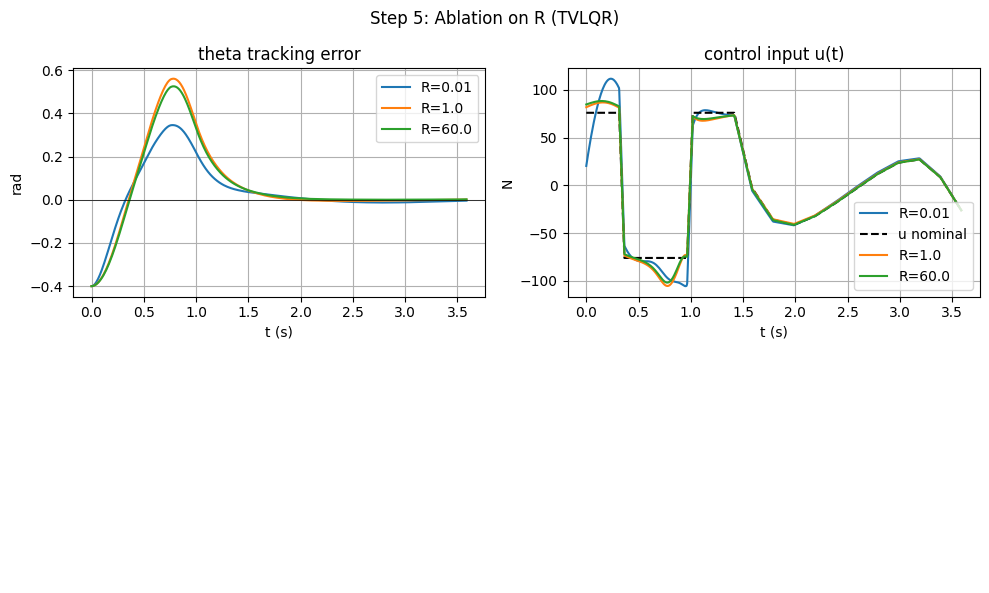

R_scale | settle_time(s) | u_peak
  0.01 | 0.296          | 111.61
  1.00 | 0.332          | 105.25
 60.00 | 0.335          | 101.74


In [20]:
# 先得到约束轨迹
xtraj, utraj = solve_constrained_trajectory(scale=0.7)
if xtraj is None:
    raise RuntimeError("约束轨迹求解失败")

# 定义扰动与对比的 R 权重
x0_perturb = np.array([0.1, -0.4, 0.2, 0.0])
R_scales = [0.01, 1.0, 60.0]  # 小R更激进，大R更保守
results = []

for r in R_scales:
    state_log, input_log = simulate_tvlqr_with_R(
        xtraj, utraj, R_scale=r, x0_perturb=x0_perturb
    )
    results.append((r, state_log, input_log))

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()
u_nom_plotted = False
summary = []
for r, state_log, input_log in results:
    ts = state_log.sample_times()
    x_nom = xtraj.vector_values(ts)
    u_nom = utraj.vector_values(ts)
    x_act = state_log.data()
    u_act = input_log.data()
    theta_err = x_act[1, :] - x_nom[1, :]
    axes[0].plot(ts, theta_err, label=f"R={r}")
    axes[1].plot(ts, u_act[0, :], label=f"R={r}")
    if not u_nom_plotted:
        axes[1].plot(ts, u_nom[0, :], "k--", label="u nominal")
        u_nom_plotted = True
    t_settle = settling_time(theta_err, ts, tol=0.05)
    u_peak = float(np.max(np.abs(u_act[0, :])))
    summary.append((r, t_settle, u_peak))

axes[0].axhline(0.0, color="k", linewidth=0.5)
axes[0].set_title("theta tracking error")
axes[0].set_xlabel("t (s)")
axes[0].set_ylabel("rad")
axes[0].grid(True)
axes[0].legend()

axes[1].set_title("control input u(t)")
axes[1].set_xlabel("t (s)")
axes[1].set_ylabel("N")
axes[1].grid(True)
axes[1].legend()

axes[2].axis("off")
axes[3].axis("off")
plt.suptitle("Step 5: Ablation on R (TVLQR)")
plt.tight_layout()
plt.show()

print("R_scale | settle_time(s) | u_peak")
for r, t_settle, u_peak in summary:
    t_str = f"{t_settle:.3f}" if np.isfinite(t_settle) else "nan"
    print(f"{r:6.2f} | {t_str:14s} | {u_peak:6.2f}")

消融 2：固定 $R$，改变 $Q$ 权重。

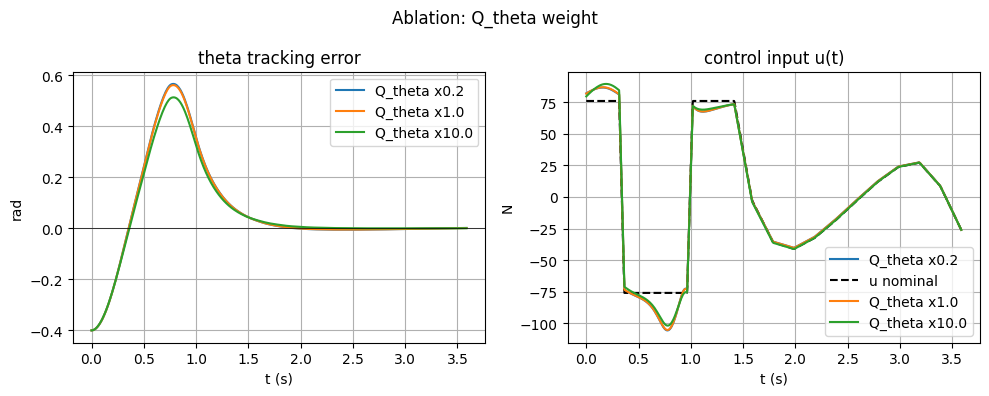

Q_theta_scale | settle_time(s) | u_peak
        0.20 | 0.331          | 105.61
        1.00 | 0.332          | 105.25
       10.00 | 0.331          | 101.81


In [21]:
# Q_theta 消融
def simulate_tvlqr_with_QR(xtraj, utraj, Q_theta_scale=1.0, R_scale=1.0, x0_perturb=None):
    options = FiniteHorizonLinearQuadraticRegulatorOptions()
    options.x0 = xtraj
    options.u0 = utraj
    Q = np.diag([10.0, 50.0 * Q_theta_scale, 1.0, 5.0])
    R = np.array([[1.0 * R_scale]])
    options.Qf = Q

    builder = DiagramBuilder()
    plant, _ = AddMultibodyPlantSceneGraph(builder, time_step=0.0)
    parser = Parser(plant)
    ConfigureParser(parser)
    parser.AddModelsFromUrl("package://underactuated/models/cartpole.urdf")
    plant.Finalize()
    context = plant.CreateDefaultContext()
    options.input_port_index = plant.get_actuation_input_port().get_index()

    regulator = builder.AddSystem(
        MakeFiniteHorizonLinearQuadraticRegulator(
            plant,
            context,
            t0=utraj.start_time(),
            tf=utraj.end_time(),
            Q=Q,
            R=R,
            options=options,
        )
    )
    builder.Connect(regulator.get_output_port(0), plant.get_actuation_input_port())
    builder.Connect(plant.get_state_output_port(), regulator.get_input_port(0))

    state_logger = LogVectorOutput(plant.get_state_output_port(), builder)
    input_logger = LogVectorOutput(regulator.get_output_port(0), builder)

    diagram = builder.Build()
    simulator = Simulator(diagram)
    sim_context = simulator.get_mutable_context()
    plant_context = plant.GetMyMutableContextFromRoot(sim_context)

    x0 = np.ravel(xtraj.value(utraj.start_time()))
    if x0_perturb is not None:
        x0 = x0 + np.ravel(x0_perturb)
    plant.SetPositionsAndVelocities(plant_context, x0)

    simulator.AdvanceTo(utraj.end_time())
    state_log = state_logger.FindLog(sim_context)
    input_log = input_logger.FindLog(sim_context)
    return state_log, input_log

Q_theta_scales = [0.2, 1.0, 10.0]
results_q = []
for q_scale in Q_theta_scales:
    state_log, input_log = simulate_tvlqr_with_QR(
        xtraj, utraj, Q_theta_scale=q_scale, R_scale=1.0, x0_perturb=x0_perturb
    )
    results_q.append((q_scale, state_log, input_log))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
u_nom_plotted = False
summary_q = []
for q_scale, state_log, input_log in results_q:
    ts = state_log.sample_times()
    x_nom = xtraj.vector_values(ts)
    u_nom = utraj.vector_values(ts)
    x_act = state_log.data()
    u_act = input_log.data()
    theta_err = x_act[1, :] - x_nom[1, :]
    axes[0].plot(ts, theta_err, label=f"Q_theta x{q_scale}")
    axes[1].plot(ts, u_act[0, :], label=f"Q_theta x{q_scale}")
    if not u_nom_plotted:
        axes[1].plot(ts, u_nom[0, :], "k--", label="u nominal")
        u_nom_plotted = True
    t_settle = settling_time(theta_err, ts, tol=0.05)
    u_peak = float(np.max(np.abs(u_act[0, :])))
    summary_q.append((q_scale, t_settle, u_peak))

axes[0].axhline(0.0, color="k", linewidth=0.5)
axes[0].set_title("theta tracking error")
axes[0].set_xlabel("t (s)")
axes[0].set_ylabel("rad")
axes[0].grid(True)
axes[0].legend()

axes[1].set_title("control input u(t)")
axes[1].set_xlabel("t (s)")
axes[1].set_ylabel("N")
axes[1].grid(True)
axes[1].legend()

plt.suptitle("Ablation: Q_theta weight")
plt.tight_layout()
plt.show()

print("Q_theta_scale | settle_time(s) | u_peak")
for q_scale, t_settle, u_peak in summary_q:
    t_str = f"{t_settle:.3f}" if np.isfinite(t_settle) else "nan"
    print(f"{q_scale:12.2f} | {t_str:14s} | {u_peak:6.2f}")

消融 3：改变约束比例（和我们在 step 3 做的一样）。

In [22]:
# 约束比例消融
scale_list = [0.7, 0.8, 0.9]
summary_scale = []
for scale in scale_list:
    xtraj_s, utraj_s = solve_constrained_trajectory(scale=scale)
    if xtraj_s is None:
        summary_scale.append((scale, np.nan, np.nan, "fail"))
        continue
    state_log, input_log = simulate_tvlqr_with_R(
        xtraj_s, utraj_s, R_scale=1.0, x0_perturb=x0_perturb
    )
    ts_s = state_log.sample_times()
    x_nom_s = xtraj_s.vector_values(ts_s)
    theta_err = state_log.data()[1, :] - x_nom_s[1, :]
    t_settle = settling_time(theta_err, ts_s, tol=0.05)
    u_peak = float(np.max(np.abs(input_log.data()[0, :])))
    summary_scale.append((scale, t_settle, u_peak, "ok"))

print("scale | settle_time(s) | u_peak | status")
for scale, t_settle, u_peak, status in summary_scale:
    t_str = f"{t_settle:.3f}" if np.isfinite(t_settle) else "nan"
    u_str = f"{u_peak:.2f}" if np.isfinite(u_peak) else "nan"
    print(f"{scale:5.2f} | {t_str:14s} | {u_str:6s} | {status}")

无约束极值: |x|max=1.114, |u|max=108.492
设置约束: |x|<=L=0.780, |u|<=u_max=75.944
无约束极值: |x|max=1.114, |u|max=108.492
设置约束: |x|<=L=0.891, |u|<=u_max=86.793
无约束极值: |x|max=1.114, |u|max=108.492
设置约束: |x|<=L=1.003, |u|<=u_max=97.642
scale | settle_time(s) | u_peak | status
 0.70 | 0.332          | 105.25 | ok
 0.80 | 0.334          | 118.06 | ok
 0.90 | 0.340          | 131.76 | ok
